In [3]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    4
)

model.load_state_dict(
    torch.load(
        "../models/resnet18_brain_tumor.pth",
        map_location="cpu"
    )
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [5]:
from brisc_project.brisc import get_data_loader

test_loader, classes = get_data_loader(
    r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\classification_task\test",
    batch_size=1
)

image, label = next(iter(test_loader))

with torch.no_grad():
    output = model(image)
    prediction = output.argmax(dim=1)

print("Actual:", classes[label.item()])
print("Predicted:", classes[prediction.item()])

Actual: pituitary
Predicted: pituitary


In [6]:
correct_image = None
correct_label = None
correct_prediction = None

model.eval()

with torch.no_grad():
    for image, label in test_loader:
        output = model(image)
        prediction = output.argmax(dim=1)

        actual_class = classes[label.item()]
        predicted_class = classes[prediction.item()]

        if actual_class != "no_tumor" and actual_class == predicted_class:
            correct_image = image
            correct_label = label
            correct_prediction = prediction
            break

print("Actual:", classes[correct_label.item()])
print("Predicted:", classes[correct_prediction.item()])

Actual: meningioma
Predicted: meningioma


In [7]:
image, label = next(iter(test_loader))

In [8]:
torch.save(
    model.state_dict(),
    "../models/resnet18_brain_tumor.pth"
)

In [9]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [10]:
model.zero_grad()

output = model(correct_image)

class_idx = correct_prediction.item()
score = output[:, class_idx]

score.backward()

In [11]:
weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1).squeeze()

cam = torch.relu(cam)

cam = cam - cam.min()
cam = cam / cam.max()

cam = cam.detach().numpy()

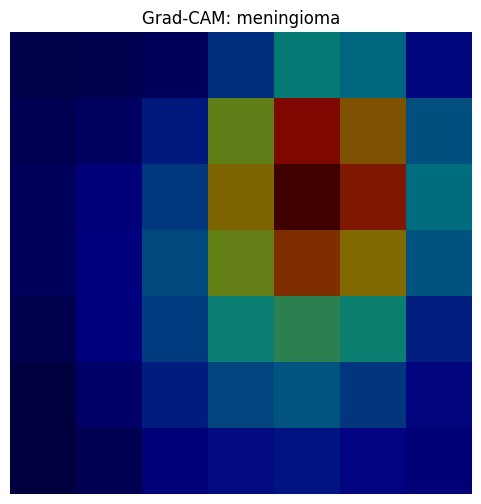

In [12]:
import matplotlib.pyplot as plt
import numpy as np

img = correct_image.squeeze().permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM: {classes[class_idx]}")
plt.axis("off")
plt.show()

In [13]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)

attributions = ig.attribute(
    correct_image,
    target=correct_prediction.item()
)

C:\Users\ccai2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


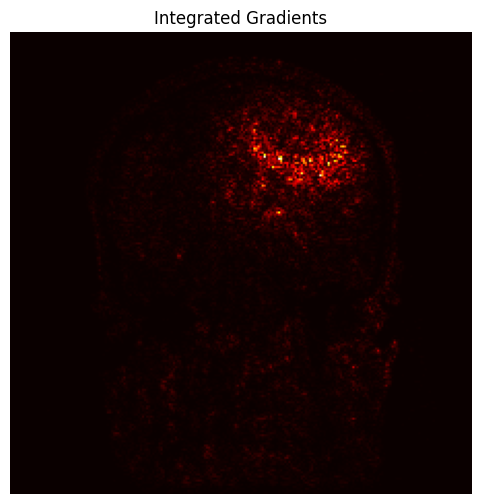

In [14]:
attr = attributions.squeeze().permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(6,6))
plt.imshow(np.mean(np.abs(attr), axis=2), cmap="hot")
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

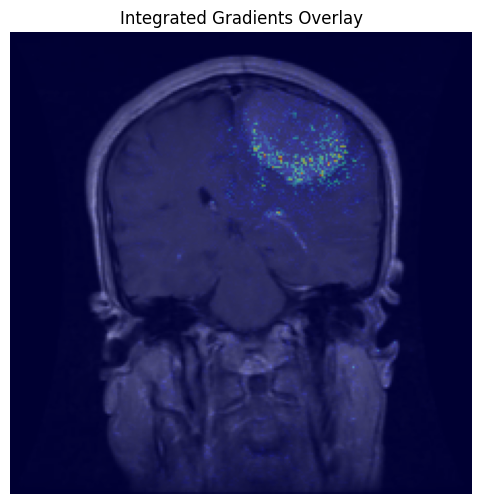

In [15]:
attr = np.mean(np.abs(attr), axis=2)

attr = (attr - attr.min()) / (attr.max() - attr.min())

img = correct_image.squeeze().permute(1, 2, 0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.imshow(attr, cmap="jet", alpha=0.4)
plt.title("Integrated Gradients Overlay")
plt.axis("off")
plt.show()

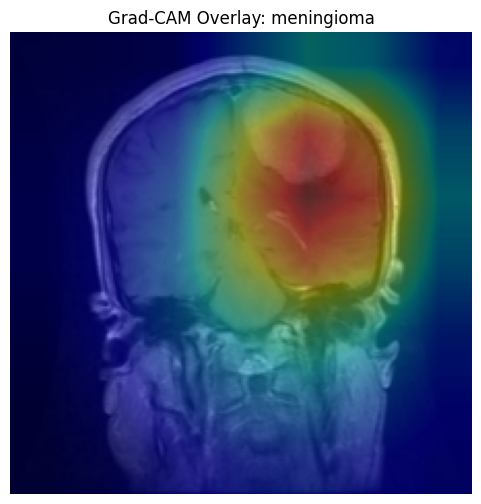

In [16]:
import cv2
import matplotlib.pyplot as plt

img = correct_image.squeeze().permute(1, 2, 0).numpy()

cam_resized = cv2.resize(
    cam,
    (img.shape[1], img.shape[0])
)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM Overlay: {classes[class_idx]}")
plt.axis("off")
plt.show()

In [17]:
import os

seg_path = r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\segmentation_task"

print(os.listdir(seg_path))

['test', 'train']


In [18]:
print(os.listdir(seg_path + r"\train")[:10])

['images', 'masks']


In [19]:
import os

image_dir = r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\segmentation_task\test\images"
mask_dir = r"C:\Users\ccai2\Downloads\brain_tumor\brisc2025\segmentation_task\test\masks"

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print(image_files[0])
print(mask_files[0])

brisc2025_test_00001_gl_ax_t1.jpg
brisc2025_test_00001_gl_ax_t1.png


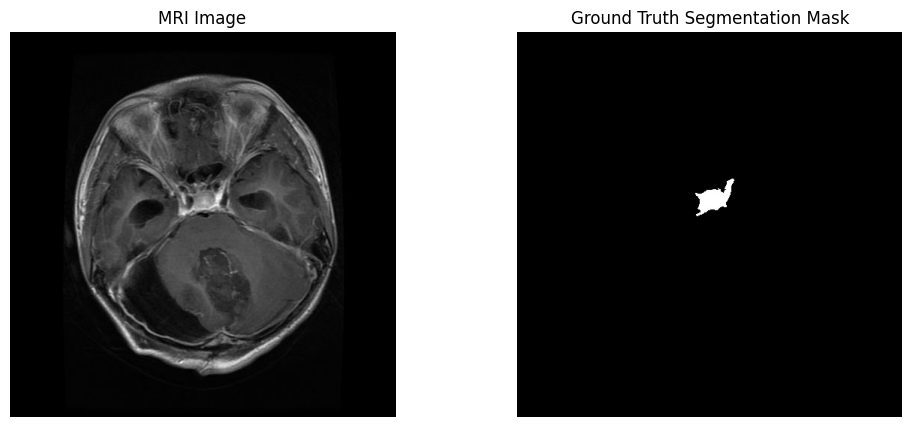

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

img_path = os.path.join(image_dir, image_files[0])
mask_path = os.path.join(mask_dir, mask_files[0])

img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Segmentation Mask")
plt.axis("off")

plt.show()

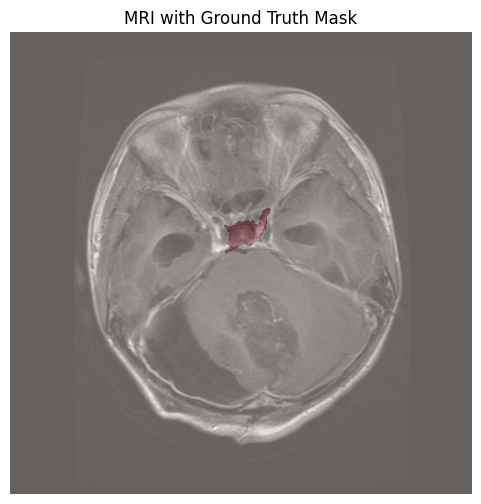

In [21]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.title("MRI with Ground Truth Mask")
plt.axis("off")
plt.show()

In [26]:
def dice_score(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    total = pred_mask.sum() + true_mask.sum()
    return (2 * intersection) / total if total > 0 else 0

def iou_score(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    return intersection / union if union > 0 else 0

In [27]:
import cv2

mask_resized = cv2.resize(
    mask,
    (cam_resized.shape[1], cam_resized.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

cam_binary = cam_resized > 0.5
mask_binary = mask_resized > 0

print("Grad-CAM Dice:", dice_score(cam_binary, mask_binary))
print("Grad-CAM IoU:", iou_score(cam_binary, mask_binary))

Grad-CAM Dice: 0.062360801781737196
Grad-CAM IoU: 0.03218390804597701


In [28]:
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    cam_binary = cam_resized > threshold
    mask_binary = mask_resized > 0

    print("Threshold:", threshold)
    print("Dice:", dice_score(cam_binary, mask_binary))
    print("IoU:", iou_score(cam_binary, mask_binary))
    print()

Threshold: 0.2
Dice: 0.02294007490636704
IoU: 0.011603125739995264

Threshold: 0.3
Dice: 0.03221388264942749
IoU: 0.016370621972270172

Threshold: 0.4
Dice: 0.047225122480122075
IoU: 0.024183597927120177

Threshold: 0.5
Dice: 0.062360801781737196
IoU: 0.03218390804597701

Threshold: 0.6
Dice: 0.0644885147667285
IoU: 0.03331859059413239

Threshold: 0.7
Dice: 0.03475771825802494
IoU: 0.01768622555139409

